In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import random
import math
import csv

%matplotlib inline

In [2]:
df=pd.read_csv('./lst_contour.csv',sep=' ')

In [3]:
lst_info=df[['x_apex','y_apex']].values
lst_info.shape

(130, 2)

In [4]:
rolled = np.roll(lst_info, 1, axis=0)

In [5]:
lst_info=np.hstack([lst_info, rolled])

In [6]:
lst_info.shape

(130, 4)

In [7]:
dist = np.linalg.norm(lst_info[:, :2] - lst_info[:, 2:], axis=1).reshape(-1, 1)
#dist = np.sqrt((lst_info[:,0] - lst_info[:,2]) ** 2 + (lst_info[:,1] - lst_info[:,3]) ** 2)

In [8]:
dist.shape

(130, 1)

In [9]:
lst_info=np.hstack([lst_info, dist])

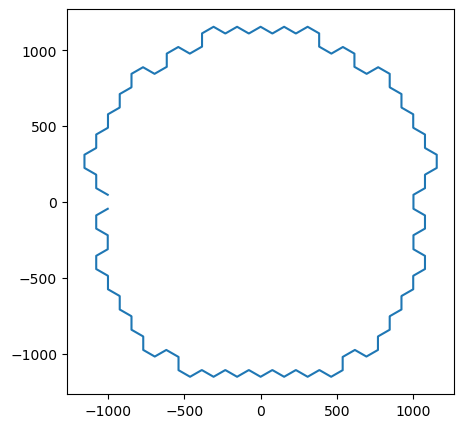

In [10]:
plt.figure(figsize=(5, 5))
plt.plot(lst_info[:,0], lst_info[:,1])
plt.show()

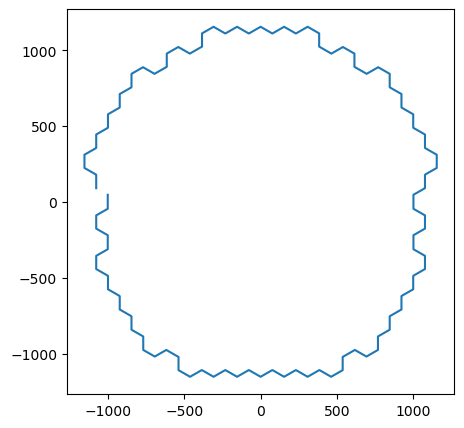

In [11]:
plt.figure(figsize=(5, 5))
plt.plot(lst_info[:,2], lst_info[:,3])
plt.show()

(array([ 28.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 102.]),
 array([ 2.99300852, 11.93170767, 20.87040682, 29.80910596, 38.74780511,
        47.68650426, 56.62520341, 65.56390256, 74.5026017 , 83.44130085,
        92.38      ]),
 <BarContainer object of 10 artists>)

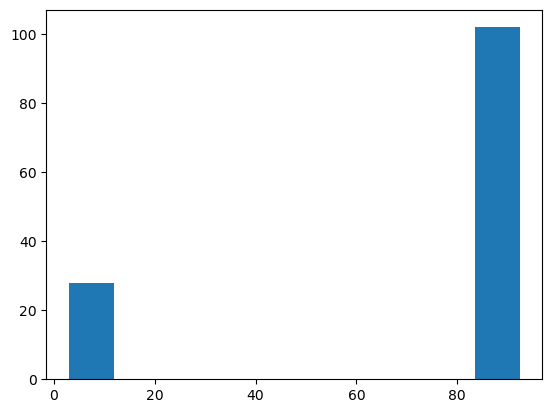

In [12]:
plt.hist(lst_info[:,-1])

In [13]:
lst_info=lst_info[lst_info[:,-1]>20]

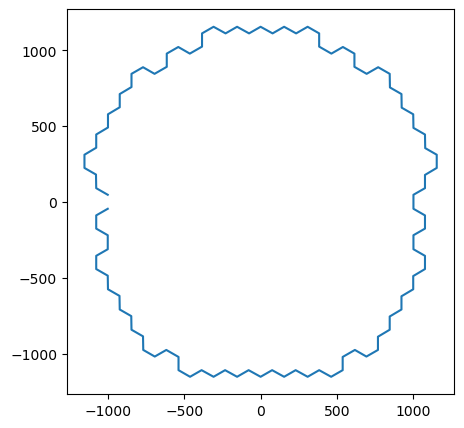

In [14]:
plt.figure(figsize=(5, 5))
plt.plot(lst_info[:,0], lst_info[:,1])
plt.show()

In [15]:
lst_info.shape[0]

102

In [45]:
lst_info[:,:4]

array([[-1.00100e+03, -4.53201e+01, -1.00100e+03,  4.70502e+01],
       [-1.07650e+03, -8.89100e+01, -1.00100e+03, -4.53201e+01],
       [-1.07650e+03, -1.76090e+02, -1.07650e+03, -8.89100e+01],
       [-1.00100e+03, -2.19680e+02, -1.07650e+03, -1.76090e+02],
       [-1.00100e+03, -3.12060e+02, -1.00100e+03, -2.19680e+02],
       [-1.07650e+03, -3.55650e+02, -1.00100e+03, -3.12060e+02],
       [-1.07650e+03, -4.42830e+02, -1.07650e+03, -3.55650e+02],
       [-1.00100e+03, -4.86420e+02, -1.07650e+03, -4.42830e+02],
       [-9.99500e+02, -5.76200e+02, -9.99500e+02, -4.89020e+02],
       [-9.24000e+02, -6.19790e+02, -9.99500e+02, -5.76200e+02],
       [-9.22500e+02, -7.09560e+02, -9.22500e+02, -6.22380e+02],
       [-8.47000e+02, -7.53150e+02, -9.22500e+02, -7.09560e+02],
       [-8.45500e+02, -8.42930e+02, -8.45500e+02, -7.55750e+02],
       [-7.70000e+02, -8.86520e+02, -8.45500e+02, -8.42930e+02],
       [-7.68500e+02, -9.76300e+02, -7.68500e+02, -8.89120e+02],
       [-6.93000e+02, -1.

In [48]:
np.savetxt("lst_contour_vi_vf.csv", lst_info[:,:4], delimiter=" ", fmt="%.3f", header="ri_x ri_y rf_x rf_y")

In [16]:
mu_x = 0
mu_y = 0
phi = 0.0
vmu_x = np.cos(phi)
vmu_y = np.sin(phi)
#mu_phi = np.linspace(0,2.0 * np.pi,10)

In [17]:
ri_x = lst_info[:,0]
ri_y = lst_info[:,1]

In [18]:
dt = np.ones(lst_info.shape[0])

In [19]:
vi_x = (lst_info[:,2] - lst_info[:,0]) / dt
vi_y = (lst_info[:,3] - lst_info[:,1]) / dt

In [20]:
c1 = mu_x - ri_x
c2 = mu_y - ri_y

In [21]:
D = vi_x * vmu_y - vi_y * vmu_x

In [22]:
t = ( c1 * vmu_y - c2 * vmu_x ) / D
s = ( vi_y * c1 - vi_x * c2 ) / D

In [30]:
status = np.column_stack((t, s))

In [39]:
mask = (status[:,0] >= 0) & (status[:,0] < 1) & (status[:,1] >= 0) 

In [42]:
status[mask]

array([[5.09365023e-01, 1.00100000e+03]])

In [25]:
#  vi_x * t + vmu_x * (-s) = mu_x - ri_x
#  vi_y * t + vmu_y * (-s) = mu_y - ri_y
#
#  c1 = rmu_x - ri_x
#  c2 = rmu_y - ri_y
#  D  = vi_x * vmu_y - vi_y * vmu_x
#  t = (   c1 * vmu_y -   c2 * vmu_x ) / D 
# -s = ( vi_x * c2    - vi_y * c1    ) / D

In [26]:
t

array([  0.49063498,   2.03969268,   2.019844  ,   5.039688  ,
         3.3780039 ,   8.15898142,   5.07949071,  11.15898142,
         6.60931406,  14.21862813,   8.13902271,  17.27804542,
         9.66884607,  20.33769213,  11.19866942,  23.39733884,
       -22.39733884,  22.13660966,  12.72849277,  26.45698555,
       -25.45698555,  26.45698555, -25.45698555,  26.45698555,
       -25.45698555,  26.45698555, -25.45698555,  26.45698555,
       -25.45698555,  26.45698555, -25.45698555,  26.45698555,
       -25.45698555, -11.72849277, -21.13660966,  23.39733884,
       -22.39733884, -10.19866942, -19.33769213,  -8.66884607,
       -16.27804542,  -7.13902271, -13.21862813,  -5.60931406,
       -10.15898142,  -4.07949071,  -7.15898142,  -2.3780039 ,
        -4.039688  ,  -1.019844  ,  -1.03969268,   0.50936502,
         2.07938307,   2.03969034,   5.13902271,   3.56951136,
         8.13902271,   5.09933471,  11.19866942,   6.62915806,
        14.25831613,   8.15898142,  17.31796284,   9.68

In [27]:
# Cartesian coordinates
#vmu_x = np.cos(phi)
#vmu_y = np.sin(phi)

In [28]:
#vmu_x

In [29]:
#vi_x